# SentinelAI — CICIDS2017 Data Analysis

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load CICIDS2017 Dataset

In [ ]:
#IMPORTING DATASET (MONDAY = NORMAL BEHAVIOUR)
import pandas as pd

df = pd.read_csv("../data/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())

(529918, 79)
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count'

## 3. Initial Dataset Inspection

In [4]:
#INFO OF MONDAY (NORMAL) DATASET
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 529918 entries, 0 to 529917
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             529918 non-null  int64  
 1    Flow Duration                529918 non-null  int64  
 2    Total Fwd Packets            529918 non-null  int64  
 3    Total Backward Packets       529918 non-null  int64  
 4   Total Length of Fwd Packets   529918 non-null  int64  
 5    Total Length of Bwd Packets  529918 non-null  int64  
 6    Fwd Packet Length Max        529918 non-null  int64  
 7    Fwd Packet Length Min        529918 non-null  int64  
 8    Fwd Packet Length Mean       529918 non-null  float64
 9    Fwd Packet Length Std        529918 non-null  float64
 10  Bwd Packet Length Max         529918 non-null  int64  
 11   Bwd Packet Length Min        529918 non-null  int64  
 12   Bwd Packet Length Mean       529918 non-null  float64


In [5]:
#UNDERSTANDING DATATYPES IN MONDAY DATASET
print(df.dtypes.value_counts())

int64      54
float64    24
str         1
Name: count, dtype: int64


In [6]:
#MONDAY IS NORMAL SO THERE IS ONLY 1 SAME LABEL - BENIGN
print(df[" Label"].value_counts())

 Label
BENIGN    529918
Name: count, dtype: int64


In [7]:
#CHECKING NULL VALUES ACCORDING TO COLUMNS
print(df.isnull().sum().sort_values(ascending=False).head(15))

Flow Bytes/s             64
 Destination Port         0
 Bwd Avg Bytes/Bulk       0
 Fwd Avg Packets/Bulk     0
Fwd Avg Bytes/Bulk        0
 Fwd Header Length.1      0
 Avg Bwd Segment Size     0
 Avg Fwd Segment Size     0
 Average Packet Size      0
 Down/Up Ratio            0
 ECE Flag Count           0
 CWE Flag Count           0
 URG Flag Count           0
 ACK Flag Count           0
 PSH Flag Count           0
dtype: int64


## 4. Explore and Validate Individual Dataset Files

In [8]:
#CHECKING ALL FILES LABEL COUNTS 
files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

for file in files:
    temp = pd.read_csv("../data/MachineLearningCVE/" + file)
    print("\n", file)
    print(temp[" Label"].value_counts())


 Monday-WorkingHours.pcap_ISCX.csv
 Label
BENIGN    529918
Name: count, dtype: int64

 Tuesday-WorkingHours.pcap_ISCX.csv
 Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64

 Wednesday-workingHours.pcap_ISCX.csv
 Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64

 Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 Label
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

 Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 Label
BENIGN          288566
Infiltration        36
Name: count, dtype: int64

 Friday-WorkingHours-Morning.pcap_ISCX.csv
 Label
BENIGN    189067
Bot         1966
Name: count, dtype: int64

 Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv

In [9]:
#BETTER OUTPUT THAN ABOVE 
for file in files:
    temp = pd.read_csv("../data/MachineLearningCVE/" + file)

    counts = temp[" Label"].value_counts()

    print("\n" + file)
    for label, count in counts.items():
        print(f"{label:25} {count:,}")


Monday-WorkingHours.pcap_ISCX.csv
BENIGN                    529,918

Tuesday-WorkingHours.pcap_ISCX.csv
BENIGN                    432,074
FTP-Patator               7,938
SSH-Patator               5,897

Wednesday-workingHours.pcap_ISCX.csv
BENIGN                    440,031
DoS Hulk                  231,073
DoS GoldenEye             10,293
DoS slowloris             5,796
DoS Slowhttptest          5,499
Heartbleed                11

Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
BENIGN                    168,186
Web Attack � Brute Force  1,507
Web Attack � XSS          652
Web Attack � Sql Injection 21

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
BENIGN                    288,566
Infiltration              36

Friday-WorkingHours-Morning.pcap_ISCX.csv
BENIGN                    189,067
Bot                       1,966

Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
PortScan                  158,930
BENIGN                    127,537

Friday-WorkingHours-Afterno

In [10]:
#PROPER FILE, LABEL AND COUNT 
summary = []

for file in files:
    temp = pd.read_csv("../data/MachineLearningCVE/" + file)

    for label, count in temp[" Label"].value_counts().items():
        summary.append({
            "file": file,
            "label": label,
            "count": count
        })

summary_df = pd.DataFrame(summary)

print(summary_df.to_string(index=False))

                                                       file                      label  count
                          Monday-WorkingHours.pcap_ISCX.csv                     BENIGN 529918
                         Tuesday-WorkingHours.pcap_ISCX.csv                     BENIGN 432074
                         Tuesday-WorkingHours.pcap_ISCX.csv                FTP-Patator   7938
                         Tuesday-WorkingHours.pcap_ISCX.csv                SSH-Patator   5897
                       Wednesday-workingHours.pcap_ISCX.csv                     BENIGN 440031
                       Wednesday-workingHours.pcap_ISCX.csv                   DoS Hulk 231073
                       Wednesday-workingHours.pcap_ISCX.csv              DoS GoldenEye  10293
                       Wednesday-workingHours.pcap_ISCX.csv              DoS slowloris   5796
                       Wednesday-workingHours.pcap_ISCX.csv           DoS Slowhttptest   5499
                       Wednesday-workingHours.pcap_ISCX.csv 

In [11]:
# CHECKING ALL FILES COLUMNS BEFORE MERGING FILES IN ONE SINGLE 
for file in files:
    temp = pd.read_csv("../data/MachineLearningCVE/" + file)

    print(file, "→", len(temp.columns), "columns")

Monday-WorkingHours.pcap_ISCX.csv → 79 columns
Tuesday-WorkingHours.pcap_ISCX.csv → 79 columns
Wednesday-workingHours.pcap_ISCX.csv → 79 columns
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv → 79 columns
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → 79 columns
Friday-WorkingHours-Morning.pcap_ISCX.csv → 79 columns
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv → 79 columns
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv → 79 columns


In [12]:
#CHECKING IF ALL FILES COLUMN NAME ARE SAME AND IN SAME ORDER OR NOT 
reference = pd.read_csv("../data/MachineLearningCVE/" + files[0])

for file in files[1:]:
    temp = pd.read_csv("../data/MachineLearningCVE/" + file)

    print(file, "→", list(reference.columns) == list(temp.columns))

Tuesday-WorkingHours.pcap_ISCX.csv → True
Wednesday-workingHours.pcap_ISCX.csv → True
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv → True
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → True
Friday-WorkingHours-Morning.pcap_ISCX.csv → True
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv → True
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv → True


## 5. Merge Dataset Files

In [13]:
#COMBINED ALL 8 FILES TOGETHER AND CHECKING ROWS AND COLUMNS

import pandas as pd

dataframes = []

for file in files:
    temp = pd.read_csv("../Data/MachineLearningCVE/" + file)
    dataframes.append(temp)

df_all = pd.concat(dataframes, ignore_index=True)

print(df_all.shape)

(2830743, 79)


In [14]:
df_all.columns = df_all.columns.str.strip()

In [15]:
print(df_all.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

## 6. Data Quality Inspection

In [16]:
#CHECKED COLUMN AND DATA TYPES 
print(df_all.info())

<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  Flow IAT Mi

### 6.1 Missing Values

In [17]:
#CHECKING NULL VALUES IN ALL COMBINED DATA 
print(df_all.isnull().sum().sort_values(ascending=False).head(20))

Flow Bytes/s              1358
Destination Port             0
Bwd Avg Bytes/Bulk           0
Fwd Avg Packets/Bulk         0
Fwd Avg Bytes/Bulk           0
Fwd Header Length.1          0
Avg Bwd Segment Size         0
Avg Fwd Segment Size         0
Average Packet Size          0
Down/Up Ratio                0
ECE Flag Count               0
CWE Flag Count               0
URG Flag Count               0
ACK Flag Count               0
PSH Flag Count               0
RST Flag Count               0
SYN Flag Count               0
FIN Flag Count               0
Packet Length Variance       0
Fwd Avg Bulk Rate            0
dtype: int64


### 6.2 Infinite Values

In [18]:
#CHECKING IF ANY VALUE IS INFINITY OR NOT 
import numpy as np

print(np.isinf(df_all.select_dtypes(include=np.number)).sum().sort_values(ascending=False).head(20))

Flow Packets/s            2867
Flow Bytes/s              1509
Destination Port             0
Down/Up Ratio                0
Fwd Avg Packets/Bulk         0
Fwd Avg Bytes/Bulk           0
Fwd Header Length.1          0
Avg Bwd Segment Size         0
Avg Fwd Segment Size         0
Average Packet Size          0
ECE Flag Count               0
Bwd Avg Bytes/Bulk           0
CWE Flag Count               0
URG Flag Count               0
ACK Flag Count               0
PSH Flag Count               0
RST Flag Count               0
SYN Flag Count               0
FIN Flag Count               0
Packet Length Variance       0
dtype: int64


### 6.3 Duplicate Rows

In [19]:
# CHECKING DUPLICATED ROWS COUNT
print("Duplicate rows:", df_all.duplicated().sum())

Duplicate rows: 308381


In [22]:

dup_mask = df_all.duplicated(keep=False)

print(df_all.loc[dup_mask, "Label"].value_counts())

Label
BENIGN                      236257
PortScan                    101501
DoS Hulk                     59564
SSH-Patator                   2826
FTP-Patator                   2457
DoS slowloris                  507
DoS Slowhttptest               323
Web Attack � Brute Force        62
DDoS                            20
Bot                             19
DoS GoldenEye                   14
Name: count, dtype: int64


In [ ]:
import numpy as np

# Check missing values
print("Missing values:")
print(df_all.isna().sum()[df_all.isna().sum() > 0])

# Check infinite values
print("\nInfinite values:")
print(np.isinf(df_all.select_dtypes(include=np.number)).sum())

Missing values:
Flow Bytes/s    1358
dtype: int64

Infinite values:
 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
 Active Min                    0
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
Length: 78, dtype: int64


In [ ]:
print("Flow Bytes/s:")
print("NaN:", df_all["Flow Bytes/s"].isna().sum())
print("Inf:", np.isinf(df_all["Flow Bytes/s"]).sum())

print("\nFlow Packets/s:")
print("NaN:", df_all[" Flow Packets/s"].isna().sum())
print("Inf:", np.isinf(df_all[" Flow Packets/s"]).sum())

Flow Bytes/s:
NaN: 1358
Inf: 1509

Flow Packets/s:
NaN: 0
Inf: 2867


In [ ]:
#CHECKING IF OTHER LABELS EXCEPT BENIGN ARE ALSO CONSISTING OF NULL VALUES OR NOT
bad_rows = (
    df_all["Flow Bytes/s"].isna()
    | np.isinf(df_all["Flow Bytes/s"])
    | np.isinf(df_all[" Flow Packets/s"])
)

print(df_all.loc[bad_rows, " Label"].value_counts())

 Label
BENIGN         1777
DoS Hulk        949
PortScan        126
Bot              10
FTP-Patator       3
DDoS              2
Name: count, dtype: int64


### 6.4 Suspicious Negative Values

In [ ]:
#CHECKED FOR NEGATIVE VALUES WHERE THEY DON'T MAKE SENSE
numeric_cols = df_all.select_dtypes(include=np.number).columns

negative_counts = (df_all[numeric_cols] < 0).sum()

print(negative_counts[negative_counts > 0])

 Flow Duration                  115
Flow Bytes/s                     85
 Flow Packets/s                 115
 Flow IAT Mean                  115
 Flow IAT Max                   115
 Flow IAT Min                  2891
 Fwd IAT Min                     17
 Fwd Header Length               35
 Bwd Header Length               22
 Fwd Header Length.1             35
Init_Win_bytes_forward      1001189
 Init_Win_bytes_backward    1441552
 min_seg_size_forward            35
dtype: int64


In [ ]:
#CHECKED WHICH VALUE APPERS AS NEGATIVE VALUES
print(df_all.loc[df_all[" Flow Duration"] < 0, 
[" Flow Duration", " Label"]].head(10))

        Flow Duration   Label
13823              -1  BENIGN
42059              -1  BENIGN
78160              -1  BENIGN
79642              -1  BENIGN
111443             -1  BENIGN
130539             -1  BENIGN
145738             -1  BENIGN
151670             -1  BENIGN
249887             -1  BENIGN
282665             -1  BENIGN


In [ ]:
print(df_all.loc[df_all[" Flow Duration"] < 0, 
[" Flow Duration", " Label"]].tail(10))

         Flow Duration   Label
2531847             -1  BENIGN
2533223             -1  BENIGN
2536401             -1  BENIGN
2548637            -13  BENIGN
2566262             -2  BENIGN
2567946             -1  BENIGN
2571061             -1  BENIGN
2602532             -1  BENIGN
2805989             -1  BENIGN
2829098             -1  BENIGN


In [ ]:
print(df_all.loc[df_all["Init_Win_bytes_forward"] < 0,
["Init_Win_bytes_forward", " Label"]].head(10))

     Init_Win_bytes_forward   Label
73                       -1  BENIGN
121                      -1  BENIGN
127                      -1  BENIGN
133                      -1  BENIGN
134                      -1  BENIGN
135                      -1  BENIGN
136                      -1  BENIGN
137                      -1  BENIGN
138                      -1  BENIGN
139                      -1  BENIGN


In [ ]:
#COULDN'T BE SURE USING HEAD AND TAIL SO SEEING WHICH WHICH NEGATIVE VALUES IT CONATINES
print("Flow Duration negative values:")
print(
    df_all.loc[df_all[" Flow Duration"] < 0, " Flow Duration"]
    .value_counts()
    .sort_index()
)

print("\nInit_Win_bytes_forward negative values:")
print(
    df_all.loc[df_all["Init_Win_bytes_forward"] < 0,
               "Init_Win_bytes_forward"]
    .value_counts()
    .sort_index()
)

Flow Duration negative values:
 Flow Duration
-13      1
-12      2
-4       1
-2       2
-1     109
Name: count, dtype: int64

Init_Win_bytes_forward negative values:
Init_Win_bytes_forward
-1    1001189
Name: count, dtype: int64


### 6.5 Label Inspection

In [ ]:
# CHECKING HOW MANY LABELS DATA IS THERE
print(df_all[" Label"].value_counts())

 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
print(df_all[" Label"].unique())

<StringArray>
[                    'BENIGN',                'FTP-Patator',
                'SSH-Patator',              'DoS slowloris',
           'DoS Slowhttptest',                   'DoS Hulk',
              'DoS GoldenEye',                 'Heartbleed',
   'Web Attack � Brute Force',           'Web Attack � XSS',
 'Web Attack � Sql Injection',               'Infiltration',
                        'Bot',                   'PortScan',
                       'DDoS']
Length: 15, dtype: str


## 7. Exploratory Data Analysis (EDA)

### 7.1 Flow Duration Analysis

In [ ]:
print(df_all.groupby(" Label")[" Flow Duration"].describe())

                                count          mean           std         min  \
 Label                                                                          
BENIGN                      2273097.0  1.122082e+07  3.012316e+07       -13.0   
Bot                            1966.0  3.509427e+05  1.968825e+06         0.0   
DDoS                         128027.0  1.695559e+07  3.101261e+07         0.0   
DoS GoldenEye                 10293.0  2.312722e+07  2.734821e+07       649.0   
DoS Hulk                     231073.0  5.708173e+07  4.601823e+07         0.0   
DoS Slowhttptest               5499.0  5.771989e+07  3.642620e+07         1.0   
DoS slowloris                  5796.0  5.655437e+07  4.951522e+07         2.0   
FTP-Patator                    7938.0  4.513245e+06  4.527256e+06         0.0   
Heartbleed                       11.0  1.106797e+08  2.850973e+07  24719667.0   
Infiltration                     36.0  7.840772e+07  4.039664e+07        20.0   
PortScan                    

In [ ]:
df_all["is_attack"] = (df_all[" Label"] != "BENIGN").astype(int)

print(df_all["is_attack"].value_counts())

is_attack
0    2273097
1     557646
Name: count, dtype: int64


In [ ]:
sample = df_all.sample(
    n=100_000,
    random_state=42
)

print(sample.shape)

(100000, 80)


Matplotlib is building the font cache; this may take a moment.


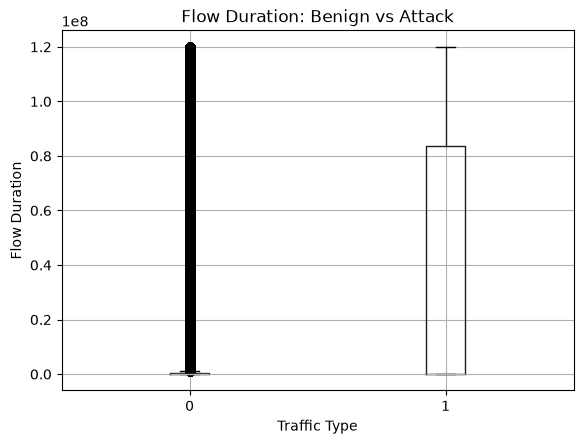

In [ ]:
import matplotlib.pyplot as plt

sample.boxplot(
    column=" Flow Duration",
    by="is_attack"
)

plt.title("Flow Duration: Benign vs Attack")
plt.suptitle("")
plt.xlabel("Traffic Type")
plt.ylabel("Flow Duration")
plt.show()

In [ ]:
print("Zero:", (sample[" Flow Duration"] == 0).sum())
print("Negative:", (sample[" Flow Duration"] < 0).sum())

Zero: 100
Negative: 3


In [ ]:
positive_sample = sample[sample[" Flow Duration"] > 0]

print(positive_sample.shape)

(99897, 80)


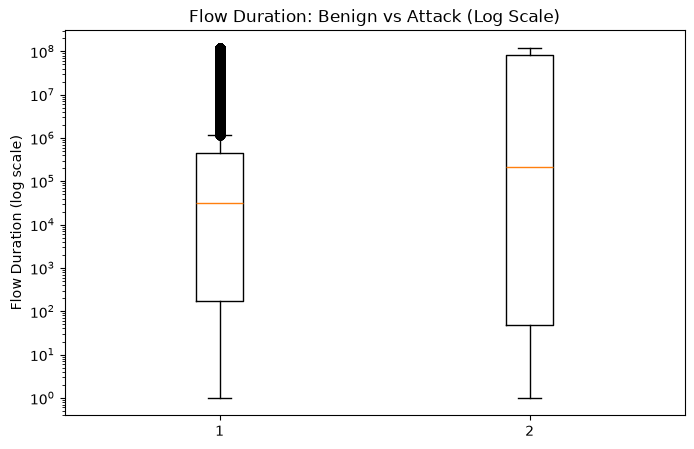

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        positive_sample.loc[
            positive_sample["is_attack"] == 0,
            " Flow Duration"
        ],
        positive_sample.loc[
            positive_sample["is_attack"] == 1,
            " Flow Duration"
        ]
    ],
    label=["BENIGN", "ATTACK"]
)

plt.yscale("log")
plt.title("Flow Duration: Benign vs Attack (Log Scale)")
plt.ylabel("Flow Duration (log scale)")
plt.show()

### 7.2 Forward Packet Analysis

In [ ]:
print(
    df_all.groupby(" Label")[" Total Fwd Packets"].median()
    .sort_values(ascending=False)
)

 Label
Heartbleed                    2792.0
Infiltration                    26.0
SSH-Patator                     14.0
DoS GoldenEye                    7.0
DoS Slowhttptest                 7.0
DoS Hulk                         6.0
FTP-Patator                      6.0
DDoS                             4.0
Web Attack � Sql Injection       4.0
Bot                              3.0
DoS slowloris                    3.0
Web Attack � Brute Force         3.0
Web Attack � XSS                 3.0
BENIGN                           2.0
PortScan                         1.0
Name:  Total Fwd Packets, dtype: float64


### 7.3 Forward Data Volume Analysis

In [ ]:
print(
    df_all.groupby(" Label")["Total Length of Fwd Packets"]
    .median()
    .sort_values(ascending=False)
)

 Label
Heartbleed                    12264.0
Infiltration                   7020.0
SSH-Patator                    1128.0
Web Attack � Sql Injection      460.0
DoS GoldenEye                   377.0
DoS Hulk                        334.0
BENIGN                           66.0
FTP-Patator                      30.5
DDoS                             26.0
DoS slowloris                    16.0
Bot                               6.0
DoS Slowhttptest                  0.0
PortScan                          0.0
Web Attack � Brute Force          0.0
Web Attack � XSS                  0.0
Name: Total Length of Fwd Packets, dtype: float64


### 7.4 Benign vs Attack Comparison

In [ ]:
print(
    df_all.groupby("is_attack")[
        [" Total Fwd Packets", "Total Length of Fwd Packets"]
    ].median()
)

            Total Fwd Packets  Total Length of Fwd Packets
is_attack                                                 
0                         2.0                         66.0
1                         3.0                         24.0


### 7.5 Class Distribution

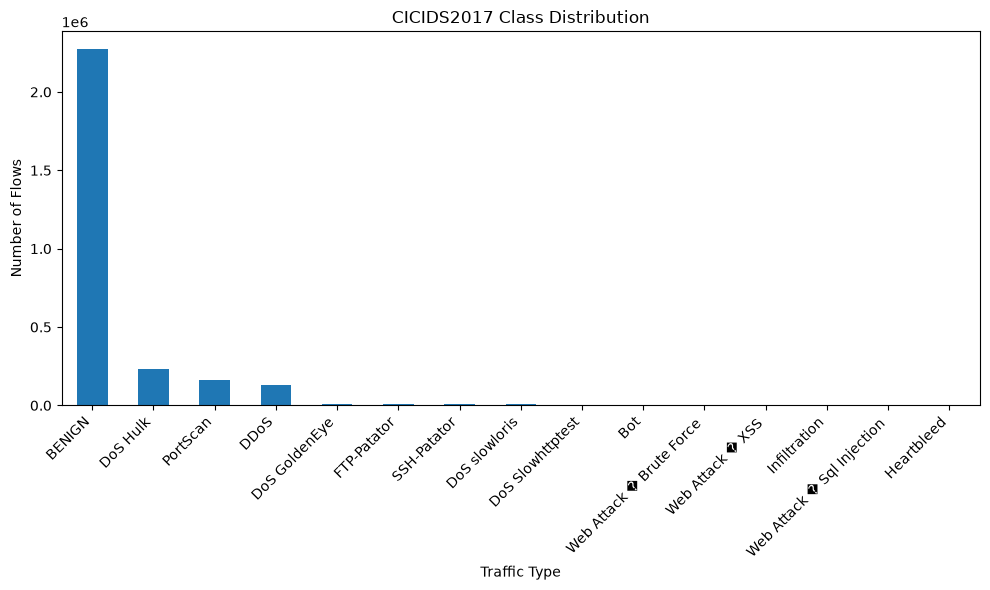

In [ ]:
import matplotlib.pyplot as plt

label_counts = df_all[" Label"].value_counts()

plt.figure(figsize=(10, 6))
label_counts.plot(kind="bar")

plt.title("CICIDS2017 Class Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Flows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

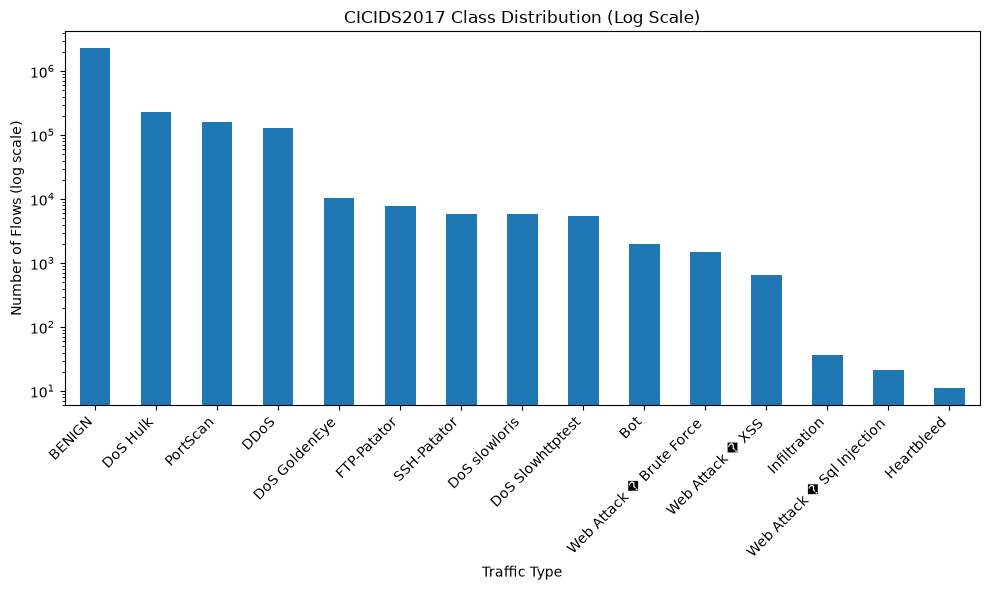

In [ ]:
plt.figure(figsize=(10, 6))

label_counts.plot(kind="bar")

plt.yscale("log")
plt.title("CICIDS2017 Class Distribution (Log Scale)")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Flows (log scale)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 7.6 Feature Correlation Analysis

In [ ]:
features = [
    " Flow Duration",
    " Total Fwd Packets",
    " Total Backward Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    " Flow Packets/s"
]

print(df_all[features].corr())

                              Flow Duration   Total Fwd Packets  \
 Flow Duration                     1.000000            0.020857   
 Total Fwd Packets                 0.020857            1.000000   
 Total Backward Packets            0.019670            0.999070   
Total Length of Fwd Packets        0.065456            0.365508   
Flow Bytes/s                      -0.025261            0.000386   
 Flow Packets/s                   -0.122429           -0.002622   

                              Total Backward Packets  \
 Flow Duration                              0.019670   
 Total Fwd Packets                          0.999070   
 Total Backward Packets                     1.000000   
Total Length of Fwd Packets                 0.359451   
Flow Bytes/s                                0.000291   
 Flow Packets/s                            -0.002762   

                             Total Length of Fwd Packets  Flow Bytes/s  \
 Flow Duration                                  0.065456     -0

## 8. Data Cleaning & Preprocessing

### Objective

The goal of this stage is to identify and handle data quality issues before feature engineering and machine learning.

The cleaning process should preserve meaningful security information while avoiding unnecessary removal of data.

We investigate each data-quality issue and apply an appropriate treatment based on its meaning.

### 8.1 Handling Missing Values

In [21]:
df_all[df_all["Flow Bytes/s"].isna()][
    ["Flow Duration", "Total Length of Fwd Packets", "Total Length of Bwd Packets", "Flow Bytes/s"]
].head()

,Flow Duration,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s
3986,0,0,0,NaN
18905,0,0,0,NaN
21063,0,0,0,NaN
21794,0,0,0,NaN
25671,0,0,0,NaN


### 8.2 Handling Infinite Values